In [1]:
from functions.cleaning_functions import convert_mmcif_to_pdb
from MDAnalysis.coordinates.memory import MemoryReader
from MDAnalysis.analysis import pca, align
from Bio.PDB import MMCIFParser, PDBIO
import MDAnalysis as mda
import pandas as pd
import numpy as np
import glob
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib 
import nglview as nv

In [2]:
targetlist = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed1_noptms/*pdb")+glob.glob("cif_files/Predictions/TMTC3/*noptm_m*pdb")+glob.glob("cif_files/Predictions/TMTC3/*3_m*pdb")+glob.glob("cif_files/Predictions/SEEDMATCHED/*seed42_ptms/*pdb") 
# for target in targetlist:
#     convert_mmcif_to_pdb(target[:-3]+"cif")
file_list_p = [target[:-3]+"pdb" for target in targetlist]

targetlist2 = glob.glob("cif_files/Predictions/notemplate/*seed1*/*cif")+glob.glob("cif_files/Predictions/notemplate/*tmtc3_nop*/*cif")+glob.glob("cif_files/Predictions/notemplate/*tmtc3_not*/*cif")+glob.glob("cif_files/Predictions/notemplate/*_ptm_*/*cif")
# for target2 in targetlist2:
#     convert_mmcif_to_pdb(target2[:-3]+"cif")
file_list2 = [target2[:-3]+"pdb" for target2 in targetlist2]


In [3]:
# Exp1 
model4_list = [file_list_p[item] for item in [4,9,14,19]]
file_list = [item for item in file_list_p if item not in model4_list]

# Exp2 Mannoses only

# file_list = file_list_p[:5]+file_list_p[-5:]
# model4_list = [file_list[item] for item in [4,-1]]
# file_list = [item for item in file_list if item not in model4_list]

In [4]:
SELEC = "index 0:1700"

universe_list = [mda.Universe(path).select_atoms(SELEC) for  path in file_list]

ref_atoms = universe_list[0]

# Align all to the first frame and collect aligned coordinates
aligned_coords = []
for mobile_atoms in universe_list:
    align.alignto(mobile_atoms, ref_atoms, select=SELEC)
    aligned_coords.append(mobile_atoms.positions.copy())
coords = np.stack(aligned_coords, axis=0)

universe_list2 = [mda.Universe(path).select_atoms(SELEC) for  path in file_list2]
aligned_coords = []
for mobile_atoms in universe_list2:
    align.alignto(mobile_atoms, ref_atoms, select=SELEC)
    aligned_coords.append(mobile_atoms.positions.copy())
coords2 = np.stack(aligned_coords, axis=0)
# # Stack coordinates into a (2, n_atoms, 3) array
# coords2 = np.stack([item.atoms.positions.copy() for item in universe_list2], axis=0)

universe_list3 = [mda.Universe(path).select_atoms(SELEC) for path in model4_list]
aligned_coords = []
for mobile_atoms in universe_list3:
    align.alignto(mobile_atoms, ref_atoms, select=SELEC)
    aligned_coords.append(mobile_atoms.positions.copy())
coords3 = np.stack(aligned_coords, axis=0)


In [5]:
def pca_on_traj(list_of_lists,SELEC="index 0:1700",listnames = ["Template","NoTemplate","model4"]):
    universe_lists = [[mda.Universe(path).select_atoms(SELEC) for  path in file_list] for file_list in list_of_lists]
    ref_atoms = universe_lists[0][0]

    # Align all to the first frame and collect aligned coordinates
    coords_all =[]
    for universe_list in universe_lists:
        aligned_coords = []
        for mobile_atoms in universe_list:
            align.alignto(mobile_atoms, ref_atoms, select=SELEC)
            aligned_coords.append(mobile_atoms.positions.copy())
        coords_all.append(np.stack(aligned_coords, axis=0))

    # run pca on first list only
    u = mda.Universe(list_of_lists[0][0])
    u.trajectory = MemoryReader(coords_all[0])
    #
    pc = pca.PCA(u,select=SELEC,align=True, mean=None,n_components=10).run()
    # 

    dfs = []
    for structures,coords,ls in zip(list_of_lists,coords_all,listnames):
        # project structure and its traj(coords) on pca
        u = mda.Universe(structures[0])
        u.trajectory = MemoryReader(coords)
        transformed = pc.transform(u.select_atoms(SELEC), n_components=3)

        df = pd.DataFrame(transformed,
                        columns=['PC{}'.format(i+1) for i in range(3)])
        df['Frame'] = df.index * u.trajectory.dt
        df["name"]= ['_'.join(path.split("fold_")[-1].split("_model")[0].split("_")[-2:]) for path in structures]
        df["list"]= ls
        df["model"]= [''.join(path.split("model_")[-1][0]) for path in structures]
        df["mannosylated"] = ["noptm" not in path for path in structures]
        df["complex"] = [("tmtc3" or "complex") in path.lower() for path in structures]
        dfs.append(df)

    return pd.concat(dfs),transformed,u,pc

In [6]:
list_of_lists=[file_list,file_list2,model4_list]
dfc,transf,u,pc = pca_on_traj(list_of_lists,"index 0:1700")


C:\Users\maxvV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\MDAnalysis\analysis\pca.py:329: DeprecationWarning: The `variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


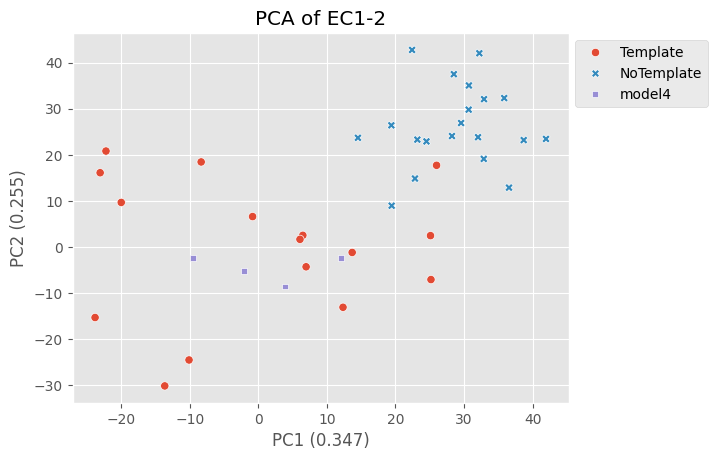

In [7]:
plt.style.use('ggplot')
plt.title("PCA of EC1-2")
sns.scatterplot(dfc,x="PC1",y="PC2",hue="list",style="list")
plt.xlabel(f"PC1 ({(pc.variance[0])/sum(pc.results.variance):.3f})")
plt.ylabel(f"PC2 ({(pc.variance[1])/sum(pc.results.variance):.3f})")
plt.legend(bbox_to_anchor=(1,1));

# stepwise PCA

In [8]:
SELEC = "index 0:1700"

In [ ]:
u = mda.Universe(file_list[0])
u.trajectory = MemoryReader(coords)
#
pc = pca.PCA(u, select=SELEC,
            align=True, mean=None,
            n_components=10).run()


In [ ]:
backbone = u.select_atoms(SELEC)
#
transformed = pc.transform(backbone, n_components=3)
df = pd.DataFrame(transformed,
                columns=['PC{}'.format(i+1) for i in range(3)])
df['Frame'] = df.index * u.trajectory.dt
df["name"]= ['_'.join(path.split("fold_")[-1].split("_model")[0].split("_")[-2:]) for path in file_list]
df["template"]="with template"
#df["model"] = [0,1,2,3]*4

In [ ]:
u2 = mda.Universe(file_list2[0])
u2.trajectory = MemoryReader(coords2)
backbone = u2.select_atoms(SELEC)
#
transformed2 = pc.transform(backbone, n_components=3)
df2 = pd.DataFrame(transformed2,
                columns=['PC{}'.format(i+1) for i in range(3)])
df2['Frame'] = df2.index * u2.trajectory.dt
df2["name"]= ['_'.join(path.split("fold_")[-1].split("_model")[0].split("_")[-2:]) for path in file_list2]
df2["template"]="notemplate"
df2["model"] = [0,1,2,3,4]*4

In [ ]:
u3 = mda.Universe(model4_list[0])
u3.trajectory = MemoryReader(coords3)
backbone = u3.select_atoms(SELEC)
#
transformed3 = pc.transform(backbone, n_components=3)
df3 = pd.DataFrame(transformed3,
                columns=['PC{}'.format(i+1) for i in range(3)])
df3['Frame'] = df3.index * u3.trajectory.dt
df3["name"]= ['_'.join(path.split("fold_")[-1].split("_model")[0].split("_")[-2:]) for path in model4_list]
df3["template"]="Model4-with template"
df3["model"]=4

In [ ]:
import plotly
import plotly.graph_objs as go
dfc = pd.concat([df,df3])
grouping = "name"
data = []
for template in dfc[grouping].unique():
    x,y,z = dfc[dfc[grouping]==template]["PC1"],dfc[dfc[grouping]==template]["PC2"],dfc[dfc[grouping]==template]["PC3"]
    trace = go.Scatter3d(x=x,y=y,z=z,mode='markers',
                            marker={'size': 5},name=template)
    
    data.append(trace)
layout = go.Layout(margin={'l': 0, 'r': 0, 'b': 0, 't': 0})

plot_figure = go.Figure(data=data, layout=layout)
plot_figure.layout.scene.camera.projection.type = "orthographic"
plot_figure.show(renderer="browser")  # remove display(fig)
plotly.offline.iplot(plot_figure)

In [ ]:
dfc = pd.concat([df,df2,df3])

c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\MDAnalysis\analysis\pca.py:360: DeprecationWarning:

The `variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.variance` instead.



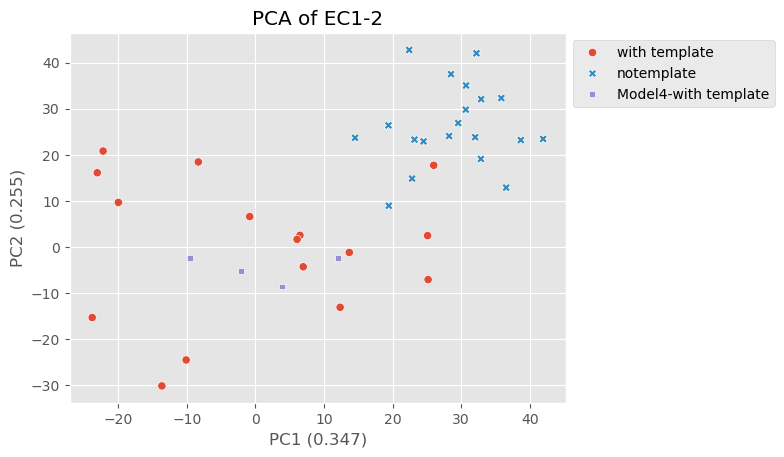

In [ ]:
plt.style.use('ggplot')
plt.title("PCA of EC1-2")
sns.scatterplot(dfc,x="PC1",y="PC2",hue="template",style="template")
plt.xlabel(f"PC1 ({(pc.variance[0])/sum(pc.results.variance):.3f})")
plt.ylabel(f"PC2 ({(pc.variance[1])/sum(pc.results.variance):.3f})")
plt.legend(bbox_to_anchor=(1,1));

In [ ]:
import plotly
import plotly.graph_objs as go

data = []
for template in dfc["template"].unique():
    x,y,z = dfc[dfc["template"]==template]["PC1"],dfc[dfc["template"]==template]["PC2"],dfc[dfc["template"]==template]["PC3"]
    trace = go.Scatter3d(x=x,y=y,z=z,mode='markers',
                            marker={'size': 5},name=template)
    
    data.append(trace)
layout = go.Layout(margin={'l': 0, 'r': 0, 'b': 0, 't': 0})

plot_figure = go.Figure(data=data, layout=layout)
plot_figure.layout.scene.camera.projection.type = "orthographic"
plot_figure.show(renderer="browser")  # remove display(fig)
plotly.offline.iplot(plot_figure)

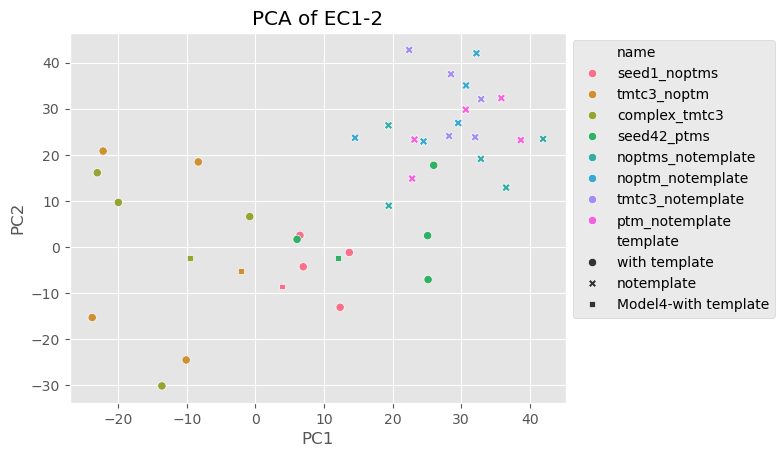

In [ ]:
plt.title("PCA of EC1-2")
sns.scatterplot(dfc,x="PC1",y="PC2",hue="name",style="template")
plt.legend(bbox_to_anchor=(1,1));

In [ ]:
from MDAnalysis.analysis import rms
SELEC = "index 0:1700 and name CA"
ref = mda.Universe("cif_files\\Crystals\\7stz_A_Monomer.pdb")
dfc["rmsdvCrystal"]=[rms.rmsd(mda.Universe(u).select_atoms(SELEC).positions,  # coordinates to align
            ref.select_atoms(SELEC).positions[:-2],  # reference coordinates
            center=True,  # subtract the center of geometry
            superposition=True) for u in file_list + file_list2 + model4_list]




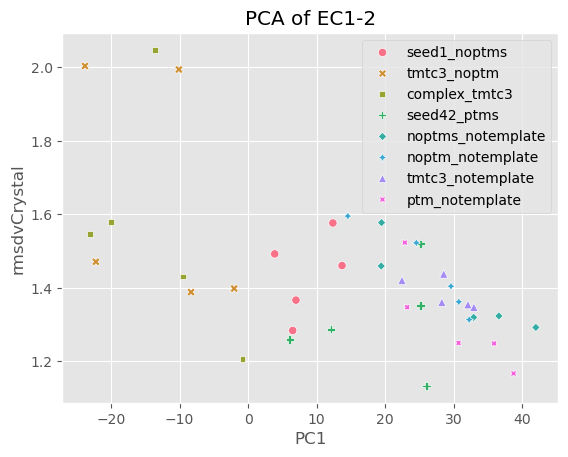

In [ ]:
plt.title("PCA of EC1-2")
sns.scatterplot(dfc,x="PC1",y="rmsdvCrystal",hue="name",style="name")

plt.legend(bbox_to_anchor=(1,1));

In [ ]:
import plotly
import plotly.graph_objs as go

data = []
grouping = "template"
marker_symbols = ['circle', 'square', 'diamond']

for template,symbol in zip(dfc[grouping ].unique(),marker_symbols):
    x,y,z = dfc[dfc[grouping ]==template]["PC1"],dfc[dfc[grouping ]==template]["PC2"],dfc[dfc[grouping ]==template]["rmsdvCrystal"]
    trace = go.Scatter3d(x=x,y=y,z=z,mode='markers',marker={'size': 5,'symbol':symbol},name=template)
    data.append(trace)
layout = go.Layout(margin={'l': 0, 'r': 0, 'b': 0, 't': 0},scene=None)

plot_figure = go.Figure(data=data, layout=layout)
#plot_figure.layout.scene.camera.projection.type = "orthographic"
plot_figure.layout.scene.xaxis.title=f"PC1 ({(pc.variance[0])/sum(pc.results.variance):.3f})"
plot_figure.layout.scene.yaxis.title=f"PC2 ({(pc.variance[1])/sum(pc.results.variance):.3f})"
plot_figure.layout.scene.zaxis.title="RMSD vs Crystal"


#plot_figure.show(renderer="browser")  # remove display(fig)
plotly.offline.iplot(plot_figure)
#plot_figure.write_html("plots/PCA.html")

c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\MDAnalysis\analysis\pca.py:360: DeprecationWarning:

The `variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.variance` instead.

